In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"


In [3]:
client=pd.read_csv(r"C:\Users\saleh\OneDrive\Desktop\CAE-Intern\project\cleanData\clean_client.csv", sep=";")
client.head()

,client_id,district_id,birth_number,gender,age
0,1,18,13-12-1970,F,26
1,2,1,04-02-1945,M,51
2,3,1,09-10-1940,F,56
3,4,5,01-12-1956,M,40
4,5,5,03-07-1960,F,36


In [5]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Ensure correct data types
client["client_id"] = client["client_id"].astype(str)
client["district_id"] = client["district_id"].astype(str)
client["birth_number"] = pd.to_datetime(client["birth_number"])

print(f"Total Unique Clients: {client['client_id'].nunique()}")
print(f"Districts Represented: {client['district_id'].nunique()}")
print(
    f"Age Range: {client['age'].min()} - {client['age'].max()} years (Mean:"
    f" {client['age'].mean():.1f})"
)

Total Unique Clients: 5369
Districts Represented: 77
Age Range: 9 - 85 years (Mean: 42.8)


C:\Users\saleh\AppData\Local\Temp\ipykernel_30500\809334677.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  client["birth_number"] = pd.to_datetime(client["birth_number"])


C:\Users\saleh\AppData\Local\Temp\ipykernel_30500\4116259082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


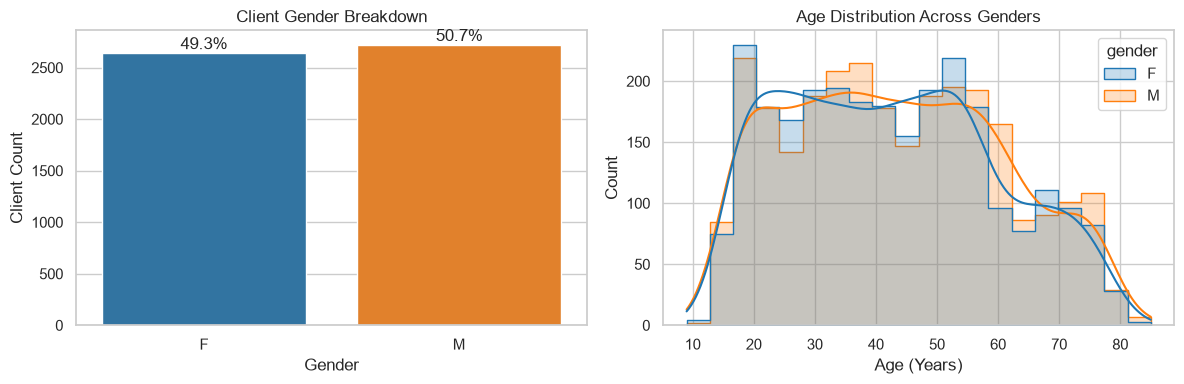

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Gender Distribution
sns.countplot(
    data=client, x="gender", palette=["#1f77b4", "#ff7f0e"], ax=axes[0]
)
axes[0].set_title("Client Gender Breakdown")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Client Count")

# Add percentage labels
total = len(client)
for p in axes[0].patches:
  pct = f"{100 * p.get_height() / total:.1f}%"
  axes[0].annotate(
      pct,
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
  )

# 2. Age Distribution by Gender
sns.histplot(
    data=client,
    x="age",
    hue="gender",
    element="step",
    bins=20,
    kde=True,
    palette=["#1f77b4", "#ff7f0e"],
    ax=axes[1],
)
axes[1].set_title("Age Distribution Across Genders")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

C:\Users\saleh\AppData\Local\Temp\ipykernel_30500\97428561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


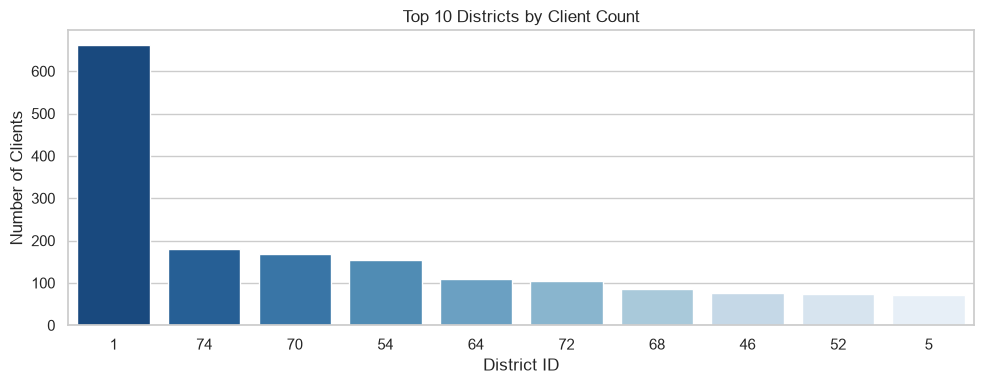

In [7]:
plt.figure(figsize=(10, 4))
top_districts = client["district_id"].value_counts().head(10)
sns.barplot(
    x=top_districts.index,
    y=top_districts.values,
    palette="Blues_r",
    order=top_districts.index,
)
plt.title("Top 10 Districts by Client Count")
plt.xlabel("District ID")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()